In [1]:
import math
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

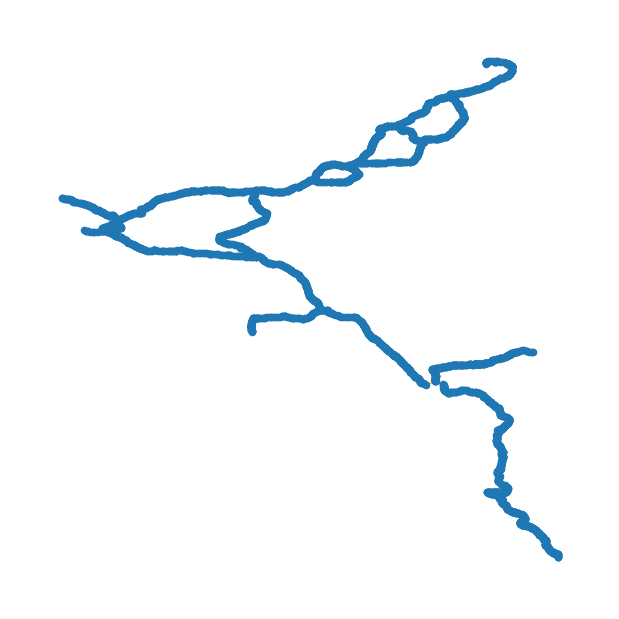

In [6]:
# Load CSV
df = pd.read_csv('../data/network_data.csv')


G = nx.Graph()

# 1. Add nodes (deduplicate by id!)
nodes = df.drop_duplicates(subset="id")

for _, row in nodes.iterrows():
    G.add_node(
        int(row["id"]),
        road=row["road"],  # first occurrence kept (fine for intersections)
        pos=(row["lon"], row["lat"]),
    )

# 2. Create edges using shift
df["from_id"] = df.groupby("road")["id"].shift(1)
df["to_id"] = df["id"]

edges = df.dropna(subset=["from_id"]).copy()

# optional: rename for clarity
edges = edges.rename(columns={"model_type": "type"})

# 3. Add edges
for _, row in edges.iterrows():
    G.add_edge(
        int(row["from_id"]),
        int(row["to_id"]),
        road=row["road"],
        type=row["type"],
        length=row["length"]
    )

# 4. Draw
pos = nx.get_node_attributes(G, "pos")

plt.figure(figsize=(6,6))
nx.draw(G, pos, node_size=20, edge_color="orange")
plt.show()